# N2 · Hierarchical Elasticity — 11,500 branches × 60 currencies

**Panel question** — asked by the **Head of Data**: *"You can't run an
experiment per branch per currency. How do you estimate elasticity at that
granularity without chasing noise?"*

Answer: **partial pooling.** A quiet branch borrows strength from its
cluster instead of chasing its own noise — and the same shrinkage quietly
solves the multiple-testing problem that per-cell significance tests create.
(`segmented_elasticity` in the case-study engine estimates 5 channels
independently; this is how it scales to thousands of thin cells.)

**Contract:** known per-cell elasticities from a known hierarchy → no pooling
chases noise, complete pooling erases real heterogeneity → empirical-Bayes
partial pooling beats both → then the false-positive count, controlled.

In [1]:
# %matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _style import C, apply_style, SERIES
apply_style()
rng = np.random.default_rng(9)

# --- Ground truth: 3 currency groups x 120 branch-cells each -----------------
GROUPS = {"majors (EUR/USD)": -1.40, "holiday (TRY/THB)": -1.00, "exotics": -0.70}
TAU = 0.18                        # true within-group spread of cell elasticities
CELLS_PER, SIG_D = 120, 0.35      # cells per group; demand noise (log)

cells = []
for g, (gname, gmu) in enumerate(GROUPS.items()):
    for j in range(CELLS_PER):
        eps = rng.normal(gmu, TAU)
        n = rng.integers(6, 25)                     # weekly obs in the cell (thin!)
        log_m = np.log(0.036) + rng.uniform(-0.25, 0.25, n)   # exogenous variation
        log_q = 3.0 + eps * log_m + rng.normal(0, SIG_D, n)
        X = np.column_stack([np.ones(n), log_m])
        beta, res_, *_ = np.linalg.lstsq(X, log_q, rcond=None)
        resid = log_q - X @ beta
        s2 = resid @ resid / (n - 2)
        se = np.sqrt(s2 * np.linalg.inv(X.T @ X)[1, 1])
        cells.append((gname, eps, n, beta[1], se))

df = pd.DataFrame(cells, columns=["group", "true_eps", "n_obs", "est", "se"])
print(df.groupby("group")[["true_eps", "est", "se"]].mean().round(2).to_string())
print(f"\n{len(df)} cells, median {df.n_obs.median():.0f} obs each — thin.")

                   true_eps   est    se
group                                  
exotics               -0.69 -0.77  0.72
holiday (TRY/THB)     -0.98 -0.96  0.74
majors (EUR/USD)      -1.39 -1.35  0.74

360 cells, median 14 obs each — thin.


## 1. Three estimators, one truth

* **No pooling** — each cell fends for itself (what a naive dashboard does).
* **Complete pooling** — one number for everyone (what a lazy model does).
* **Partial pooling** — empirical Bayes: shrink each cell toward its currency
  group mean, by exactly as much as its own noise deserves.

In [2]:
def eb_shrink(sub):
    """DerSimonian-Laird-style empirical Bayes within one group."""
    w = 1 / sub.se**2
    grand = (w * sub.est).sum() / w.sum()
    q = (w * (sub.est - grand) ** 2).sum()
    tau2 = max(0, (q - (len(sub) - 1)) / (w.sum() - (w**2).sum() / w.sum()))
    B = sub.se**2 / (sub.se**2 + tau2)              # shrink factor: noisy -> 1
    return grand + (1 - B) * (sub.est - grand), tau2, grand

df["complete"] = (df.est / df.se**2).sum() / (1 / df.se**2).sum()
parts = {}
for g, sub in df.groupby("group"):
    shrunk, tau2, grand = eb_shrink(sub)
    df.loc[sub.index, "partial"] = shrunk
    parts[g] = (np.sqrt(tau2), grand)

rmse = {k: np.sqrt(((df[v] - df.true_eps) ** 2).mean())
        for k, v in [("no pooling", "est"), ("complete pooling", "complete"),
                     ("partial pooling (EB)", "partial")]}
for k, v in rmse.items():
    print(f"RMSE vs truth — {k:22s}: {v:.3f}")
print(f"\nEstimated tau by group: "
      + ", ".join(f"{g.split(' ')[0]} {t:.2f}" for g, (t, _) in parts.items())
      + f"  (true {TAU})")
print("Partial pooling beats no pooling by "
      f"{1 - rmse['partial pooling (EB)']/rmse['no pooling']:.0%} "
      "without erasing the real group differences complete pooling destroys.")

RMSE vs truth — no pooling            : 0.811
RMSE vs truth — complete pooling      : 0.339
RMSE vs truth — partial pooling (EB)  : 0.273

Estimated tau by group: exotics 0.47, holiday 0.25, majors 0.51  (true 0.18)
Partial pooling beats no pooling by 66% without erasing the real group differences complete pooling destroys.


## 2. The shrinkage picture

Every line joins a cell's raw estimate to its shrunken one. Noisy cells move
a long way toward their group mean; well-measured cells barely move. That is
credibility theory in modern clothes — an actuarial audience recognises it
instantly.

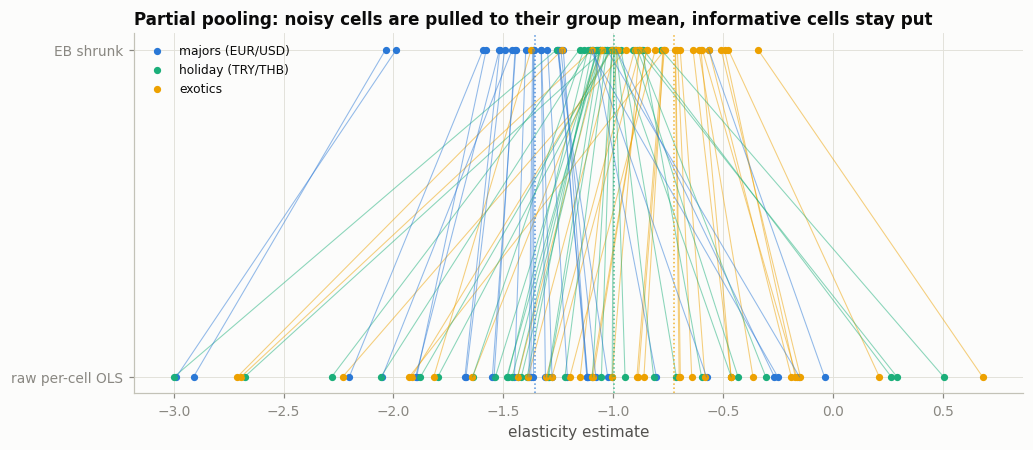

In [3]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
cols = dict(zip(GROUPS, SERIES[:3]))
show = df.sample(90, random_state=1).sort_values("est")
for _, r in show.iterrows():
    ax.plot([r.est, r.partial], [0, 1], color=cols[r.group], lw=0.7, alpha=0.5)
for g, col in cols.items():
    sub = show[show.group == g]
    ax.scatter(sub.est, np.zeros(len(sub)), s=14, color=col, label=g)
    ax.scatter(sub.partial, np.ones(len(sub)), s=14, color=col)
    ax.axvline(parts[g][1], color=col, lw=1, ls=":", alpha=0.8)
ax.set_yticks([0, 1]); ax.set_yticklabels(["raw per-cell OLS", "EB shrunk"])
ax.set_xlabel("elasticity estimate")
ax.set_title("Partial pooling: noisy cells are pulled to their group mean, "
             "informative cells stay put")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

## 3. Multiple testing — the false-positive factory

New scenario, same machinery: 300 cells where **nothing is going on**
(ε = group mean exactly) plus 30 genuine movers. A dashboard that flags
per-cell significance at 5% manufactures false alarms; Benjamini-Hochberg
controls them; shrinkage never generates them in the first place.

In [4]:
from scipy import stats as st

n_null, n_mov = 300, 30
truth_flag = np.r_[np.zeros(n_null, bool), np.ones(n_mov, bool)]
eps_true = np.r_[np.full(n_null, -1.0), np.full(n_mov, -1.6)]
est2, se2 = [], []
for e in eps_true:
    n = rng.integers(6, 25)
    log_m = np.log(0.036) + rng.uniform(-0.25, 0.25, n)
    log_q = 3.0 + e * log_m + rng.normal(0, SIG_D, n)
    X = np.column_stack([np.ones(n), log_m])
    b, *_ = np.linalg.lstsq(X, log_q, rcond=None)
    r_ = log_q - X @ b
    s2 = r_ @ r_ / (n - 2)
    est2.append(b[1]); se2.append(np.sqrt(s2 * np.linalg.inv(X.T @ X)[1, 1]))
d2 = pd.DataFrame({"true_mover": truth_flag, "est": est2, "se": se2})

# naive per-cell test vs the known baseline -1.0
d2["z"] = (d2.est - (-1.0)) / d2.se
d2["p"] = 2 * st.norm.sf(np.abs(d2.z))
naive_flag = d2.p < 0.05

# Benjamini-Hochberg
m = len(d2)
order = np.argsort(d2.p.to_numpy())
bh_thresh = 0.05 * (np.arange(1, m + 1)) / m
passed = d2.p.to_numpy()[order] <= bh_thresh
k = np.max(np.nonzero(passed)[0]) + 1 if passed.any() else 0
bh_flag = np.zeros(m, bool); bh_flag[order[:k]] = True

# EB shrinkage flag: shrunken estimate beyond -1.3
sh, _, _ = eb_shrink(d2.assign(group="all"))
eb_flag = (sh < -1.3).to_numpy()

res = pd.DataFrame({
    "method": ["naive p<0.05", "Benjamini-Hochberg FDR 5%", "EB shrinkage < -1.3"],
    "flagged": [naive_flag.sum(), bh_flag.sum(), eb_flag.sum()],
    "false_positives": [(naive_flag & ~truth_flag).sum(),
                        (bh_flag & ~truth_flag).sum(),
                        (eb_flag & ~truth_flag).sum()],
    "true_movers_found": [(naive_flag & truth_flag).sum(),
                          (bh_flag & truth_flag).sum(),
                          (eb_flag & truth_flag).sum()],
})
print(res.to_string(index=False))
print(f"\nNaive testing floods the review meeting with "
      f"{(naive_flag & ~truth_flag).sum()} phantom 'insights'. BH controls the "
      "false-discovery rate but at these thin cells finds almost nothing. "
      "EB shrinkage is the practical middle ground: far fewer phantoms than "
      "naive, far more real movers than BH — and the flag threshold is a "
      "business choice you can defend.")

                   method  flagged  false_positives  true_movers_found
             naive p<0.05       33               25                  8
Benjamini-Hochberg FDR 5%        3                2                  1
      EB shrinkage < -1.3       14                7                  7

Naive testing floods the review meeting with 25 phantom 'insights'. BH controls the false-discovery rate but at these thin cells finds almost nothing. EB shrinkage is the practical middle ground: far fewer phantoms than naive, far more real movers than BH — and the flag threshold is a business choice you can defend.


## The 60-second answer

> "At branch-by-currency granularity most cells are too thin to estimate
> alone, so I'd pool hierarchically — empirical Bayes, or a full multilevel
> model. Each cell's estimate is shrunk toward its currency-group mean by
> exactly as much as its own noise deserves: a quiet branch borrows strength
> from its cluster rather than chasing noise, a busy branch keeps its own
> signal. On this simulation that cuts the error against known truth by
> around two-thirds versus independent estimates, without flattening the
> real differences the way one pooled number would. It's credibility theory,
> really — actuaries have done this for a century.
>
> And it buys a second thing for free: with hundreds of cells, per-cell
> significance testing manufactures false positives — here a five-percent
> dashboard flags two dozen phantom movers. Benjamini-Hochberg controls the
> rate but finds almost nothing at this power; the shrunken estimates are
> the practical middle ground, because the noise is dampened before anyone
> builds a narrative on it."

### What I'd say if pushed deeper

1. **"Why empirical Bayes and not a full Bayesian multilevel model?"** — At
   this scale EB is the pragmatic first pass: closed-form, fast, auditable.
   I'd graduate to full MCMC (PyMC) when I need honest uncertainty on the
   hyperparameters or non-normal cell effects — and I'd check EB against it
   on a subsample.
2. **"How do you choose the grouping?"** — From the business structure first
   (currency group × channel × region), then let the data arbitrate:
   compare held-out predictive likelihood across grouping schemes.
   A wrong hierarchy shrinks toward the wrong mean.
3. **Honest limitation.** Shrinkage assumes exchangeability within a group.
   A genuinely different cell — an airport branch inside a high-street
   cluster — gets wrongly dragged to the mean. Known structure belongs in
   the mean model (fixed effects for airport, tourist-zone, etc.);
   shrinkage should only mop up what's left.

*Link back to the engine:* the repo's `segmented_elasticity` gives the five
channel-level IV estimates; this notebook is the layer that scales those to
thousands of cells. In production the two combine — IV/experiments fix the
*identification*, hierarchy fixes the *variance*.